# Ensembl VEP Annotations









In [99]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils  
import src.ensemblVEP as ev

import matplotlib.pyplot as plt
import seaborn as sns
import pooch
from tqdm import tqdm
import polars as pl
import glob

pd.set_option('display.max_columns', None)
plt.rcParams['font.family'] =  'Nimbus Sans'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import VEP results

### ESM

In [125]:
# Focus on one model for the main plots
model_name = "esm2_t33_650M_UR50D"

force = False
tmp_vep_path = os.path.expanduser("~/projects/VEP_protein/results/data/vep_df_esm2_t33_650M_UR50D.parquet")
if os.path.exists(tmp_vep_path) and not force:
    print(f"Loading {tmp_vep_path}")
    vep_df = pd.read_parquet(tmp_vep_path)
# "Location" is already in the dataframe 
# Set cached annotation file path
cached_file = os.path.join(pooch.os_cache("pooch"), "cv_annot_ProteinGym_missense.parquet")

### Add site column in the same format as EnsemblVEP
# Fast vectorized conversion of CLNHGVS like "NC_000023.11:g.154563582C>G" to "chrX:154563582-154563583_C_G"
import re

# Only operate on rows where both CLNHGVS and #CHROM are not null
mask = vep_df["CLNHGVS"].notnull() & vep_df["#CHROM"].notnull()
clnhgvs = vep_df.loc[mask, "CLNHGVS"]

# Use pandas str.extract for vectorized regex extraction
# This regex will also allow for multi-base ref/alt alleles (e.g., "g.154563582_154563584delinsAT")
# For now, keep the original regex, but we will use the length of alt for the end position
extracted = clnhgvs.str.extract(r".+:g\.(\d+)([ACGT]+)>([ACGT]+)")
# extracted columns: 0=pos, 1=ref, 2=alt

# Only keep rows where extraction succeeded (all groups matched)
valid = extracted.notnull().all(axis=1)
idx = clnhgvs.index[valid]
chroms = vep_df.loc[idx, "#CHROM"]
pos = extracted.loc[valid, 0].astype(int)
ref = extracted.loc[valid, 1]
alt = extracted.loc[valid, 2]

# Calculate end position as pos + len(alt)
end_pos = pos + (alt.str.len())

# Build the site string
site_str = "chr" + chroms + ":" + pos.astype(str) + "-" + end_pos.astype(str) + "_" + ref + "_" + alt

# Assign to the correct rows in vep_df["site"]
vep_df["site"] = None
vep_df.loc[idx, "site"] = site_str.values
 
vep_df.head() 

Loading /home/schilder/projects/VEP_protein/results/data/vep_df_esm2_t33_650M_UR50D.parquet


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,site,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,chr7:150947347-150947348_G_A,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025,NaN,ClinGen:CA008015,None,None,None,NaN,NaN,-6.731237,-0.021689,6,benign
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,chr7:150947473-150947474_C_A,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402,NaN,ClinGen:CA007791,None,None,None,NaN,NaN,-2.509515,-0.039753,6,likely_path
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,chr7:150947493-150947494_T_A,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,None,None,None,NaN,NaN,-5.869637,-0.057342,6,likely_path
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,chr7:150947639-150947640_C_T,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G>A,NP_000229.1:p.Glu978Lys,-,0.00008,0.00039,78349,"EFO:EFO_0004269,Human_Phenotype_Ontology:HP:00...",Cardiac_arrhythmia|Cardiovascular_phenotype|no...,NC_000007.14

### SpliceAI

In [137]:
model_name = "SpliceAI"

spliceai_df_path = "../data/1000_Genomes_on_GRCh38/SpliceAI/spliceai_clinvar_merged.parquet"
vep_df = pd.read_parquet(spliceai_df_path) 

# Set cached annotation file path
cached_file = os.path.join(pooch.os_cache("pooch"), "cv_annot_SpliceVarDB_splicing.parquet")

vep_df["Location"] = (
    vep_df["chromosome"].str.removeprefix("chr").astype(str)
    + ":"
    + vep_df["position"].astype(str)
    + "-"
    + (vep_df["position"]).astype(str)
) 

### All others (Flashzoi)

In [93]:
model_name = "Flashzoi"

variant_set="clinvar_utr_snv"
xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set
)

pq_file = os.path.join(xr_mfds_dir, "vep_df.parquet")  
vep_df = pd.read_parquet(pq_file)

vep_df["VEP"] = vep_df["flashzoi"]
vep_df["Location"] = vep_df["chrom"].astype(str) + ":" + vep_df["chromStart"].astype(str) + "-" + vep_df["chromStart"].astype(str)

# Set cached annotation file path
cached_file = os.path.join(pooch.os_cache("pooch"), "cv_annot_ClinVar_UTR.parquet")

## Filter and merge annotation files

In [ ]:
# df = pd.read_csv(cached_file.replace(".parquet",".csv.gz")  , low_memory=False)
# df.to_parquet(cached_file)


In [142]:
cv_annot = ev.filter_annotations(
    df= vep_df,
    df_filters = {"Location": "Location"}, 
    cache_search = os.path.join(os.path.expanduser("~/projects/data/ensemblVEP"), "clinvarVEP*"),
    cached_file = cached_file,
    # force = True
)  
cv_annot.head()

Reading from /home/schilder/.cache/pooch/cv_annot_SpliceVarDB_splicing.parquet
Extracting numeric values from SIFT and PolyPhen columns
Computing statistics from MaveDB_score column


<string>:63: RuntimeWarning: Mean of empty slice
<string>:64: RuntimeWarning: Mean of empty slice
<string>:65: RuntimeWarning: All-NaN axis encountered
<string>:66: RuntimeWarning: All-NaN axis encountered


Creating chrom and chromStart columns
Adding variant name column
Adding mutant column
Adding ENST column
(27841, 490)


,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SOURCE,SIFT,PolyPhen,miRNA,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,OpenTargets_geneId,OpenTargets_l2g,CADD_PHRED,CADD_RAW,Mastermind_MMID3,Geno2MP_HPO_count,Geno2MP_URL,ada_score,rf_score,BLOSUM62,Enformer_SAD,Enformer_SAR,NMD,EVE_CLASS,EVE_SCORE,5UTR_annotation,5UTR_consequence,Existing_InFrame_oORFs,Existing_OutOfFrame_oORFs,Existing_uORFs,PHENOTYPES,IntAct_ap_ac,IntAct_feature_ac,IntAct_feature_annotation,IntAct_feature_short_label,IntAct_feature_type,IntAct_interaction_ac,IntAct_interaction_participants,IntAct_pmid,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,pHaplo,pTriplo,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,RiboseqORFs_CDS_position,RiboseqORFs_amino_acids,RiboseqORFs_cDNA_position,RiboseqORFs_codons,RiboseqORFs_consequences,RiboseqORFs_id,RiboseqORFs_impact,RiboseqORFs_protein_position,RiboseqORFs_publications,ClinPred,LOEUF,GO,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,1000Gp3_AC,1000Gp3_AF,1000Gp3_AFR_AC,1000Gp3_AFR_AF,1000Gp3_AMR_AC,1000Gp3_AMR_AF,1000Gp3_EAS_AC,1000Gp3_EAS_AF,1000Gp3_EUR_AC,1000Gp3_EUR_AF,1000Gp3_SAS_AC,1000Gp3_SAS_AF,ALFA_African_AC,ALFA_African_AF,ALFA_African_AN,ALFA_African_American_AC,ALFA_African_American_AF,ALFA_African_American_AN,ALFA_African_Others_AC,ALFA_African_Others_AF,ALFA_African_Others_AN,ALFA_Asian_AC,ALFA_Asian_AF,ALFA_Asian_AN,ALFA_East_Asian_AC,ALFA_East_Asian_AF,ALFA_East_Asian_AN,ALFA_European_AC,ALFA_European_AF,ALFA_European_AN,ALFA_Latin_American_1_AC,ALFA_Latin_American_1_AF,ALFA_Latin_American_1_AN,ALFA_Latin_American_2_AC,ALFA_Latin_American_2_AF,ALFA_Latin_American_2_AN,ALFA_Other_AC,ALFA_Other_AF,ALFA_Other_AN,ALFA_Other_Asian_AC,ALFA_Other_Asian_AF,ALFA_Other_Asian_AN,ALFA_South_Asian_AC,ALFA_South_Asian_AF,ALFA_South_Asian_AN,ALFA_Total_AC,ALFA_Total_AF,ALFA_Total_AN,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_rankscore,AlphaMissense_score,AltaiNeandertal,BayesDel_addAF_pred,BayesDel_addAF_rankscore,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_rankscore,BayesDel_noAF_score,ChagyrskayaNeandertal,DANN_rankscore,DANN_score,DEOGEN2_pred,DEOGEN2_rankscore,DEOGEN2_score,Denisova,ESM1b_pred,ESM1b_rankscore,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-PC-raw_coding_rankscore,Eigen-phred_coding,Eigen-raw_coding,Eigen-raw_coding_rankscore,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,GERP++_RS_rankscore,GERP_91_mammals,GERP_91_mammals_rankscore,Interpro_domain,LIST-S2_pred,LIST-S2_rankscore,LIST-S2_score,MPC_rankscore,MPC_score,MVP_rankscore,MVP_score,MetaLR_pred,MetaLR_rankscore,MetaLR_score,MetaRNN_pred,MetaRNN_rankscore,MetaRNN_score,MetaSVM_pred,MetaSVM_rankscore,MetaSVM_score,MutFormer_rankscore,MutFormer_score,MutationAssessor_pred,MutationAssessor_rankscore,MutationAssessor_score,MutationTaster_converted_rankscore,MutationTaster_model,MutationTaster_pred,MutationTaster_score,MutationTaster_trees_beni

In [143]:
# Aggregate VEP scores
if "is_ref" not in vep_df.columns:
    vep_df["is_ref"] = vep_df["sample"] == "REF"
agg_cols = [x for x in ["is_ref","site","spliceogenicity","CLNSIG_simplified","clinsig"] if x in vep_df.columns]
vep_agg = vep_df.groupby(agg_cols, observed=True).agg({"VEP": "mean"}).reset_index()
print("vep_agg.shape:",vep_agg.shape)

# Merge VEP scores with ClinVar annotations
on_cols = ["site"]
rm_cols = [col for col in cv_annot.columns if col not in on_cols and col in vep_agg.columns]
vep_annot = vep_agg.drop(columns=rm_cols).merge(cv_annot.drop_duplicates(subset="site"), on=on_cols, how="inner")
print("vep_annot.shape:",vep_annot.shape)
vep_annot.head() 

vep_agg.shape: (16469, 5)
vep_annot.shape: (6038, 494)


,is_ref,site,spliceogenicity,CLNSIG_simplified,VEP,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SOURCE,SIFT,PolyPhen,miRNA,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,OpenTargets_geneId,OpenTargets_l2g,CADD_PHRED,CADD_RAW,Mastermind_MMID3,Geno2MP_HPO_count,Geno2MP_URL,ada_score,rf_score,BLOSUM62,Enformer_SAD,Enformer_SAR,NMD,EVE_CLASS,EVE_SCORE,5UTR_annotation,5UTR_consequence,Existing_InFrame_oORFs,Existing_OutOfFrame_oORFs,Existing_uORFs,PHENOTYPES,IntAct_ap_ac,IntAct_feature_ac,IntAct_feature_annotation,IntAct_feature_short_label,IntAct_feature_type,IntAct_interaction_ac,IntAct_interaction_participants,IntAct_pmid,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,pHaplo,pTriplo,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,RiboseqORFs_CDS_position,RiboseqORFs_amino_acids,RiboseqORFs_cDNA_position,RiboseqORFs_codons,RiboseqORFs_consequences,RiboseqORFs_id,RiboseqORFs_impact,RiboseqORFs_protein_position,RiboseqORFs_publications,ClinPred,LOEUF,GO,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,1000Gp3_AC,1000Gp3_AF,1000Gp3_AFR_AC,1000Gp3_AFR_AF,1000Gp3_AMR_AC,1000Gp3_AMR_AF,1000Gp3_EAS_AC,1000Gp3_EAS_AF,1000Gp3_EUR_AC,1000Gp3_EUR_AF,1000Gp3_SAS_AC,1000Gp3_SAS_AF,ALFA_African_AC,ALFA_African_AF,ALFA_African_AN,ALFA_African_American_AC,ALFA_African_American_AF,ALFA_African_American_AN,ALFA_African_Others_AC,ALFA_African_Others_AF,ALFA_African_Others_AN,ALFA_Asian_AC,ALFA_Asian_AF,ALFA_Asian_AN,ALFA_East_Asian_AC,ALFA_East_Asian_AF,ALFA_East_Asian_AN,ALFA_European_AC,ALFA_European_AF,ALFA_European_AN,ALFA_Latin_American_1_AC,ALFA_Latin_American_1_AF,ALFA_Latin_American_1_AN,ALFA_Latin_American_2_AC,ALFA_Latin_American_2_AF,ALFA_Latin_American_2_AN,ALFA_Other_AC,ALFA_Other_AF,ALFA_Other_AN,ALFA_Other_Asian_AC,ALFA_Other_Asian_AF,ALFA_Other_Asian_AN,ALFA_South_Asian_AC,ALFA_South_Asian_AF,ALFA_South_Asian_AN,ALFA_Total_AC,ALFA_Total_AF,ALFA_Total_AN,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_rankscore,AlphaMissense_score,AltaiNeandertal,BayesDel_addAF_pred,BayesDel_addAF_rankscore,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_rankscore,BayesDel_noAF_score,ChagyrskayaNeandertal,DANN_rankscore,DANN_score,DEOGEN2_pred,DEOGEN2_rankscore,DEOGEN2_score,Denisova,ESM1b_pred,ESM1b_rankscore,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-PC-raw_coding_rankscore,Eigen-phred_coding,Eigen-raw_coding,Eigen-raw_coding_rankscore,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,GERP++_RS_rankscore,GERP_91_mammals,GERP_91_mammals_rankscore,Interpro_domain,LIST-S2_pred,LIST-S2_rankscore,LIST-S2_score,MPC_rankscore,MPC_score,MVP_rankscore,MVP_score,MetaLR_pred,MetaLR_rankscore,MetaLR_score,MetaRNN_pred,MetaRNN_rankscore,MetaRNN_score,MetaSVM_pred,MetaSVM_rankscore,MetaSVM_score,MutFormer_rankscore,MutFormer_score,MutationAssessor_pred,MutationAssessor_rankscore,MutationAssessor_score,MutationTaster_converted_rankscore,MutationTaster_model,MutationTaster_p

Compute correlations between VEP scores and EnsemblVEP annotations. 

Then compare the difference in VEP scores between reference-derived VEPs and averaged non-reference-derived (personalized) VEPs.

In [144]:
r2_df = ev.run_correlation_analysis(vep_annot, 
                                    ANNOT_COLS=ev.ANNOT_COLS, 
                                    # transform="exp2", 
                                    # method="pearson"
                                    )

Calculating Spearman r:   0%|          | 0/133 [00:00<?, ?it/s]

Calculating Spearman r:   6%|▌         | 8/133 [00:00<00:03, 37.85it/s]/home/schilder/projects/VEP_DNA/src/ensemblVEP.py:386: UserWarning: Error converting VEP and MPC_score to float
  vep_annot_sub.loc[:, col] = vep_annot_sub[col].astype(float)
/home/schilder/projects/VEP_DNA/src/ensemblVEP.py:386: UserWarning: Error converting VEP and MetaRNN_score to float
  vep_annot_sub.loc[:, col] = vep_annot_sub[col].astype(float)
Calculating Spearman r:  21%|██        | 28/133 [00:00<00:02, 41.85it/s]/home/schilder/projects/VEP_DNA/src/ensemblVEP.py:386: UserWarning: Error converting VEP and gMVP_score to float
  vep_annot_sub.loc[:, col] = vep_annot_sub[col].astype(float)
/home/schilder/projects/VEP_DNA/src/ensemblVEP.py:386: UserWarning: Error converting VEP and PROVEAN_pred to float
  vep_annot_sub.loc[:, col] = vep_annot_sub[col].astype(float)
/home/schilder/projects/VEP_DNA/src/ensemblVEP.py:386: UserWarning: Error converting VEP and PROVEAN_score to float
  vep_annot_sub.loc[:, col] = vep


R2 Results Summary:
           annotation     ref_r  nonref_r    r_diff  rabs_diff   r2_diff  \
53       Enformer_SAR -0.103445 -0.094647  0.008798  -0.008798 -0.001743   
52       Enformer_SAD -0.098607 -0.090105  0.008502  -0.008502 -0.001604   
39        mutfunc_mod  0.041692  0.048858  0.007167   0.007167  0.000649   
32          EVE_SCORE  0.103471  0.109142  0.005671   0.005671  0.001206   
13  Reliability_index -0.097905 -0.092894  0.005011  -0.005011 -0.000956   
..                ...       ...       ...       ...        ...       ...   
56             AMR_AF -0.016920 -0.050537 -0.033617   0.033617  0.002268   
90         1000Gp3_AF -0.036751 -0.073899 -0.037147   0.037147  0.004110   
93     1000Gp3_EAS_AF  0.009804 -0.029060 -0.038864   0.019255  0.000748   
92     1000Gp3_AMR_AF -0.006563 -0.045860 -0.039297   0.039297  0.002060   
40      mutfunc_motif       NaN       NaN       NaN        NaN       NaN   

    ref_n  nonref_n     ref_p  nonref_p  ref_fdr  nonref_fdr  comb

Partial explanation of EnsemblVEP columns:
- https://useast.ensembl.org/info/docs/tools/vep/vep_formats.html#tab

In [118]:
# r2_df.loc[r2_df["ref_p"]<0.05, "ref_r"] = 0
# r2_df.loc[r2_df["nonref_p"]<0.05, "nonref_r"] = 0
# r2_df["r_diff"] = r2_df["nonref_r"] - r2_df["ref_r"]

# r2_df["combined_diff"] = (r2_df["nonref_r"] *(1-r2_df["nonref_p"])) - (r2_df["ref_r"] *(1-r2_df["ref_p"]))
# r2_df["combined_abs_diff"] = (r2_df["nonref_r"].abs() *(1-r2_df["nonref_p"])) - (r2_df["ref_r"].abs() *(1-r2_df["ref_p"]))
# r2_df["combined2_diff"] = (r2_df["nonref_r"] *(1-r2_df["nonref_p"])).pow(2) - (r2_df["ref_r"] *(1-r2_df["ref_p"])).pow(2)


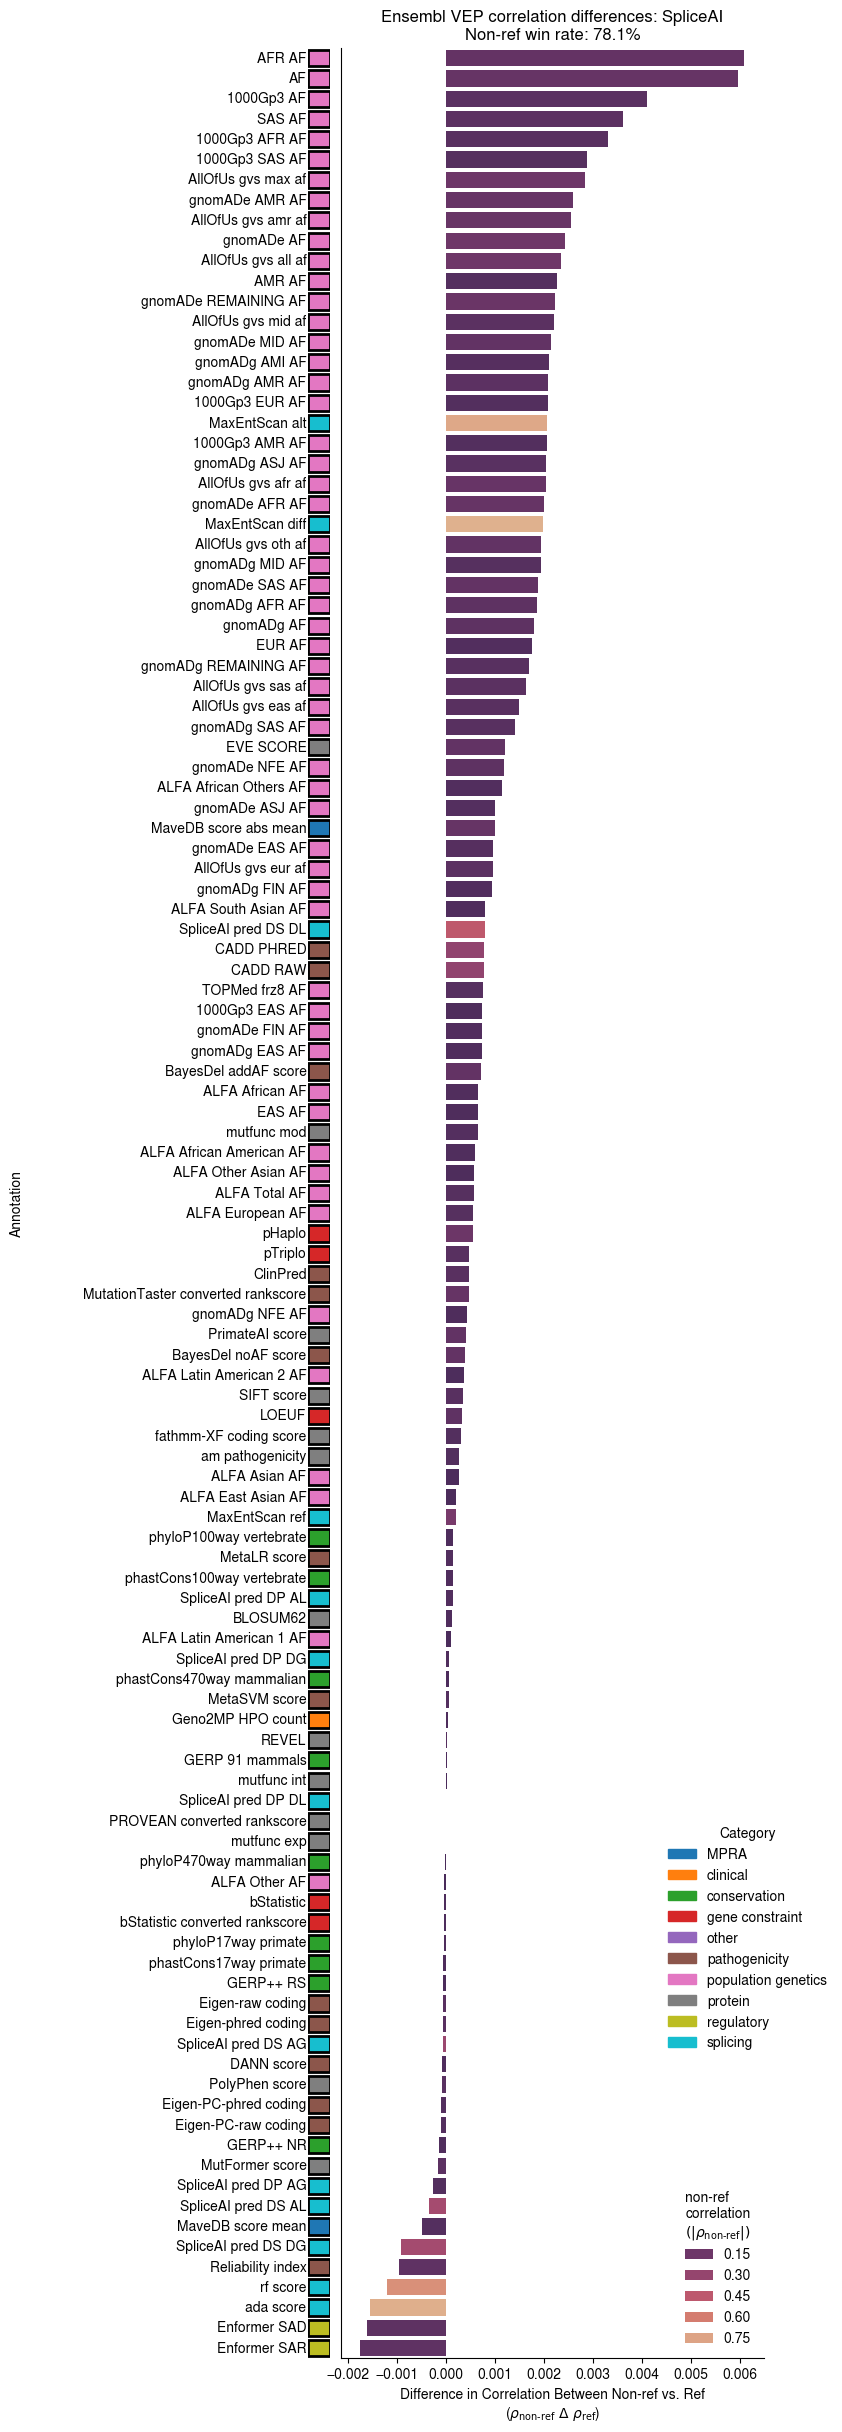

In [145]:

plot_correlation_analysis_out = ev.plot_correlation_analysis(r2_df.dropna(axis=1, how='all').dropna(axis=0, how='all'), 
                                       x_var="r2_diff",
                                       show_category_column=True,
                                       category_palette="tab10", 
                                        # min_n=20,
                                        # max_p=0.05,
                                        # min_diff=1e-10,
                                        title=f"Ensembl VEP correlation differences: {model_name}",
                                        # annotations=[x for x in ev.ANNOT_COLS if not x.lower().endswith("af") and "SpliceAI" not in x],
                                        figsize=(6, 30))
plot_correlation_analysis_out['fig'].savefig(f"tmp/vep_correlation_differences_{model_name}.pdf", **utils.FIG_SAVE_KWARGS)                                        